In [1]:
# import the usual suspects
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from src.cf_generator_dice import DiceCFGenerator
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.utils import load_config,check_file_exists,print_balancing, plot_confusion_ascii, write_time
from src.fancy_plots import build_cmap
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score, roc_auc_score,balanced_accuracy_score


from typing import Any,Dict

# Data Loadining


In [2]:
from src.fancy_plots import build_cmap, gold_map
from seaborn import cm


In [3]:
# let's find the different files we need
config = load_config('config.yaml')
cf_results = config['paths']['counterfactuals']
dt_name = "german_credit"

cf_results

'counterfactuals/'

In [4]:
data_processor = DataProcessor(config=config)
splits = data_processor.load_splits(dt_name)


Loaded feature names from data/processed/german_credit/feature_names.csv
Loaded X_train from data/processed/german_credit/X_train.npz
Loaded y_train from data/processed/german_credit/y_train.npz
Loaded X_test from data/processed/german_credit/X_test.npz
Loaded y_test from data/processed/german_credit/y_test.npz
Loaded X_calibration from data/processed/german_credit/X_calibration.npz
Loaded y_calibration from data/processed/german_credit/y_calibration.npz


# Model Loading


In [5]:

model_trainer = ModelTrainer(config)
models = model_trainer.train_model(X_train=splits['X_train'], 
                                    y_train=splits['y_train'], 
                                    X_test=splits['X_test'], 
                                    y_test=splits['y_test'],
                                    dataset_name=dt_name)
print(models.keys())

Processing random_forest for german_credit
Loaded random_forest model from models/german_credit/random_forest.pkl
Loaded existing random_forest model
Processing mlp for german_credit
Loaded mlp model from models/german_credit/mlp.pkl
Loaded existing mlp model
Processing xgboost for german_credit
Loaded xgboost model from models/german_credit/xgboost.pkl
Loaded existing xgboost model
Processing lgbm for german_credit
Loaded lgbm model from models/german_credit/lgbm.pkl
Loaded existing lgbm model
dict_keys(['random_forest', 'mlp', 'xgboost', 'lgbm'])


In [6]:
for k in models.keys():
    roc = roc_auc_score(splits['y_test'], models[k].predict_proba(splits['X_test'])[:,1]).round(2)
    print(f"Model {k} ROC AUC: {roc}")
    acc = accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Accuracy: {acc}")
    f1_ = f1_score(splits['y_test'], models[k].predict(splits['X_test']), average='weighted').round(2)
    print(f"Model {k} F1 Score: {f1_}")
    balanced_accuracy = balanced_accuracy_score(splits['y_test'], models[k].predict(splits['X_test'])).round(2)
    print(f"Model {k} Balanced Accuracy: {balanced_accuracy}")
    #print(classification_report(splits['y_test'], models[k].predict(splits['X_test'])))
    plot_confusion_ascii(splits['y_test'], models[k].predict(splits['X_test']),ascii_set=5)
    # print(confusion_matrix(splits['y_test'], models[k].predict(splits['X_test']))
    print()
    

Model random_forest ROC AUC: 0.8


Model random_forest Accuracy: 0.75
Model random_forest F1 Score: 0.72
Model random_forest Balanced Accuracy: 0.62
◑•
•◑

Model mlp ROC AUC: 0.72
Model mlp Accuracy: 0.74
Model mlp F1 Score: 0.73
Model mlp Balanced Accuracy: 0.65
◈○
∙◐

Model xgboost ROC AUC: 0.77
Model xgboost Accuracy: 0.74
Model xgboost F1 Score: 0.73
Model xgboost Balanced Accuracy: 0.65
◈○
∙◐

Model lgbm ROC AUC: 0.78
Model lgbm Accuracy: 0.74
Model lgbm F1 Score: 0.73
Model lgbm Balanced Accuracy: 0.65
◑○
•◐



In [7]:
# import the fancy for bar chart tdqm
from  tqdm.notebook import tqdm,tnrange, tqdm_notebook
import time



## Selective Classification:
Improves reliability by allowing the model to abstain from making predictions for uncertain samples (rejected samples).

Plug-In Rule: A method for calibrating models for selective classification based on specified coverage levels.

## Performance Metrics:

   - Non-Rejected Accuracy (AN): Accuracy of predictions for samples not rejected.
   - Classification Quality (CQ): A holistic measure of model performance (possibly combining coverage and accuracy).
   - Rejection Quality (RQ): A measure of how well rejected predictions match the expected quality.

In [8]:
from typing import Any, Dict
from OLD_src.Lib.L2R.code.model_agnostic import PlugInRule, PlugInRuleAUC, SCRoss
from OLD_src.MyLoreSA.metrics import nonrejected_accuracy, classification_quality, rejection_quality, rejection_classification_report

In [9]:
markers = ["o","d","s","v"]
colors = ["blue","red","green","purple"]


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
class CFRejector(ClassifierMixin,BaseEstimator):
    """
    Class for the Counterfactual Rejection Model
    It takes as input a classifier and constructs a rejection model based on the distance of the counterfactuals
    """
    def __init__(self,model,cf_generator = "dice",
                            method = None,
                            ):
        # here have to be initialized the counterfactual generator
        self.cf_generator = cf_generator

    def fit(self, X, y, sample_weight=None):
        """
        :param X:
        :param y:
        :param sample_weight:
        :return:
        """

        # here we store the classes
        self.classes = np.unique(y)

        self.model.fit(X, y)
        # quantiles
    def predict_proba(self, X):
        if hasattr(self.model, "predict_proba"):
            return self.model.predict_proba(X)
        else:
            raise AttributeError(
                "The original model does not have predict_proba method."
            )

    def predict(self, X):
        return np.argmax(self.predict_proba(X), axis=1)

In [57]:
# Selective Classifiers
# the keys are the models
plug_in_rulers = {}
selected_plg = {}
plug_in_rulers_auc = {}
selected_plg_auc = {}

# the values are:
# - rejection_quality_dict: the rejection quality of the model
# - plug_in_rulers: the plug-in ruler of the models
# - rejected_by_coverage: the number of samples rejected by the coverage
# - classification_quality_dict: the classification quality of the model () 
rejected_by_coverage = {}
classification_quality_dict = {}
rejection_quality_dict = {}
included_samples = {}
all_original_scores = {}
# the target coverages
target_coverages_n = 30
target_coverages = np.linspace(0.001,1,target_coverages_n-6)[::-1][1:]
target_coverages = sorted(list(set(target_coverages))+[0.5,0.9,0.95,0.99,0.01,0.05],reverse=True)
target_coverages_n = len(target_coverages)
n = len(splits['X_test'])

# initialize the dictionaries for the results
for k in models.keys():
    plug_in_rulers[k] =  PlugInRule(model=models[k])
    # Probably I will have to change this to the version that do not refit the model
    plug_in_rulers_auc[k] = PlugInRuleAUC(model=models[k])
    all_original_scores[k] = accuracy_score(splits['y_test'], models[k].predict(splits['X_test']))
    
    # the following are the dictionaries for the results, one for each selective technique
    rejected_by_coverage[k] = {}
    classification_quality_dict[k] = {}
    rejection_quality_dict[k] = {}
    included_samples[k] = {}
    for selective_c in ["PlugInRule","PlugInRuleAUC"]:
        rejected_by_coverage[k][selective_c] = np.zeros(target_coverages_n)
        classification_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
        rejection_quality_dict[k][selective_c] = np.zeros(target_coverages_n)
    
        included_samples[k][selective_c] = np.zeros(target_coverages_n)


metric_dicts = {
    "rejected_by_coverage":rejected_by_coverage,
    "classification_quality_dict":classification_quality_dict,
    "rejection_quality_dict":rejection_quality_dict,
    "included_samples":included_samples
}    

#### Auxiliary functions
We start by defining some auxiliary functions that we will use later on.

In [58]:
from src.utils import compute_selective_metrics

In [59]:
for jj,k in enumerate(models.keys()):
    print("Model",k)
    ###########################
    ## SELECTIVE CLASSIFIERS ##
    ###########################
    # create the plug in rule
    plug_in_rule = plug_in_rulers[k]
    #target_coverages = [.99, .75, .50, ...] 
    plug_in_rule.calibrate(splits["X_calibration"], target_coverages=target_coverages)
    # here we create an array containing levels for acceptance depending on how the selective classifiers are calibrated
    # since we used 100 target coverages, we have 101 levels of acceptance, i.e., 0, 1, 2, 3, ..., 100
    selected_plg[k] = plug_in_rule.qband(splits["X_test"])

    
    #scr = SCRoss(model=models[k])
    # scr.calibrate(target_coverages=target_coverages)
    plug_in_ruler_auc = plug_in_rulers_auc[k]
    # Here we calibrate the selective classifier that uses the AUC
    plug_in_ruler_auc.calibrate(X=splits["X_calibration"],
                                    y=splits["y_calibration"].values.reshape(-1),
                                    target_coverages=target_coverages)
    selected_plg_auc[k] = plug_in_rulers_auc[k].qband(splits["X_test"])
    for selective_k,selected in zip(["PlugInRule",
                                    "PlugInRuleAUC"],[1,0]):
        if selective_k == "PlugInRuleAUC":
            selected = selected_plg_auc[k]
            selected_c = plug_in_rulers_auc[k]
        if selective_k == "PlugInRule":
            selected = selected_plg[k]
            selected_c = plug_in_rulers[k]
        compute_selective_metrics(model_key=k,
                                    selected_data=selected,
                                    classifier_type=selective_k,
                                    selective_classifier=selected_c,
                                    splits=splits,
                                    target_coverages=target_coverages,
                                    n=n,
                                    metric_dicts=metric_dicts)


Model random_forest
Model mlp
Model xgboost
Model lgbm


## Plotting the metrics
We will plot the metrics for different coverage levels.

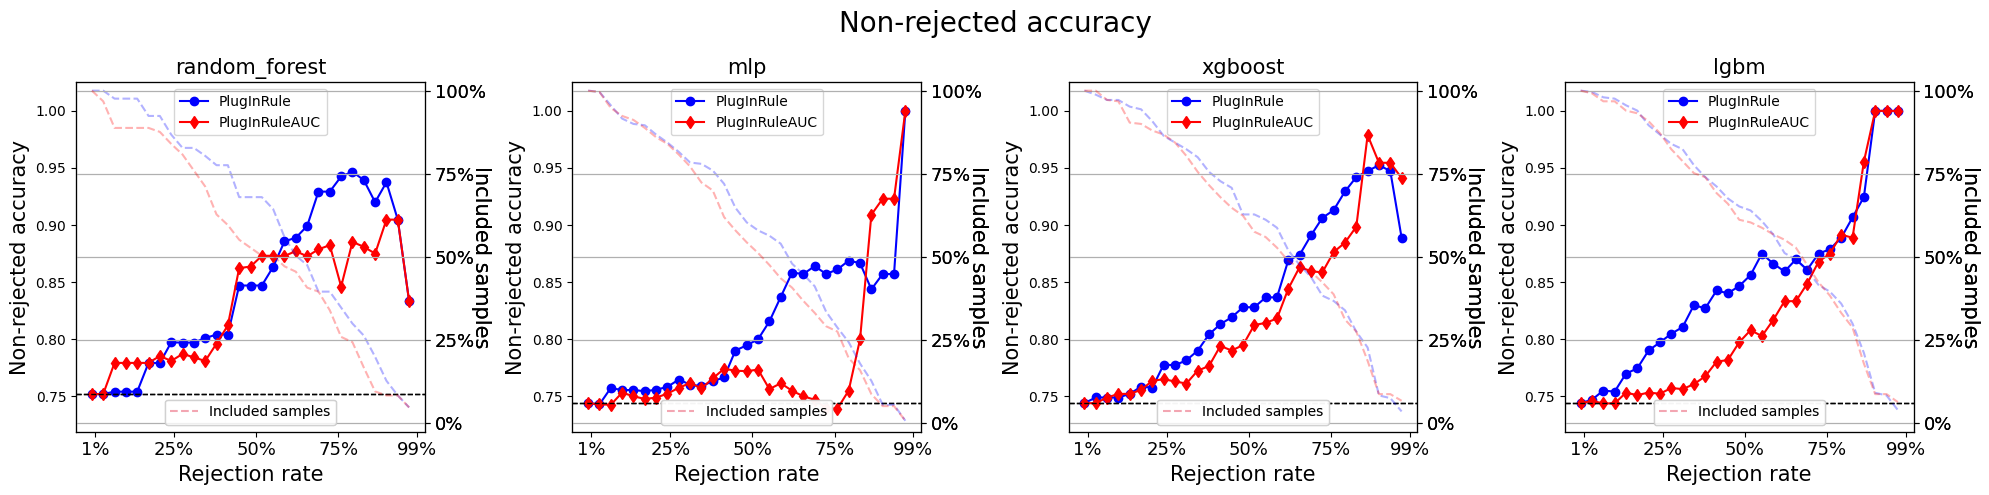

In [60]:
#iterate over the models

fig, ax = plt.subplots(1,len(models.keys()),figsize=(20,5))
ax = ax.flatten()
for jj,k in enumerate(models.keys()):
    for selective_k,marker,color in zip(["PlugInRule","PlugInRuleAUC"],
                                        markers,
                                        colors):
        rejected_acc = rejected_by_coverage[k][selective_k]
        ax[jj].plot(np.arange(len(rejected_acc))/len(rejected_acc), rejected_acc, 
                    label=selective_k,
                    marker=marker,
                    color=color)

        ax[jj].legend(loc="upper center")
        ax[jj].set_title(k,fontsize=15)
        ax[jj].set_xlabel('Rejection rate', fontsize=15)
        # set the xticks to be 1%, 25 % , 50 %, 75 % and 99
        ax[jj].set_xticks([0.01,0.25,0.5,0.75,0.99])
        # add the percentage sign
        ax[jj].set_xticklabels(['1%','25%','50%','75%','99%'], fontsize=13)
        ax[jj].set_ylabel('Non-rejected accuracy', fontsize=15)
        ax[jj].grid()
        # plot the 0% rejection accuracy
        low_y_lim = min(all_original_scores.values())
        ax[jj].set_ylim(low_y_lim-0.025,1.025)
        #ax[jj].set_ylim(0.0,1.025)
        ax[jj].axhline(all_original_scores[k],linestyle="--",
        color="black",lw=1)
        # get the twin axis
        axx2 = ax[jj].twinx()
        # plot the number of included samples in the classification
        included_samp = included_samples[k][selective_k]
        axx2.plot(np.arange(target_coverages_n)/target_coverages_n, included_samp, 
                    label="Included samples",
                    
                    color=color,
                    linestyle="--",alpha=0.3)
        axx2.set_ylabel("Included samples",fontsize=15,rotation=270)
        axx2.set_ylim(-0.025,1.025)
        # set the yticks to be 0, 25 % , 50 %, 75 % and 100 %
        axx2.set_yticks([0,0.25,0.5,0.75,1])
        # add the percentage sign
        axx2.set_yticklabels(['0%','25%','50%','75%','100%'], fontsize=13)
        axx2.grid()
        axx2.legend(loc="lower center")

plt.suptitle("Non-rejected accuracy",fontsize=20)
plt.tight_layout()
plt.show()

In [61]:
from src.utils import evaluate_coverage_accuracy

In [62]:
from importlib import reload
# reload the utils
import src.utils as utils
reload(utils)

<module 'src.utils' from '/home/vbonsignori/L2loRe/src/utils.py'>

In [64]:
for jj,k in enumerate(models.keys()):
    print("Model",k)
    for selective_k in ["PlugInRule","PlugInRuleAUC"]:
        if selective_k == "PlugInRuleAUC":
            selected_c = plug_in_rulers_auc[k]
        elif selective_k == "PlugInRule":
            selected_c = plug_in_rulers[k]
        
        utils.evaluate_coverage_accuracy(selected_c,splits=splits,percentages=[99,90,50,25,10],
        selective_classifier_name=selective_k)
    print()

Model random_forest
PlugInRule: predicting 99% of cases: 0.7520
PlugInRule: predicting 90% of cases: 0.7792
PlugInRule: predicting 50% of cases: 0.8889
PlugInRule: predicting 25% of cases: 0.9394
PlugInRule: predicting 10% of cases: 0.9375
PlugInRuleAUC: predicting 99% of cases: 0.7520
PlugInRuleAUC: predicting 90% of cases: 0.7521
PlugInRuleAUC: predicting 50% of cases: 0.8730
PlugInRuleAUC: predicting 25% of cases: 0.8462
PlugInRuleAUC: predicting 10% of cases: 0.8810

Model mlp
PlugInRule: predicting 99% of cases: 0.7430
PlugInRule: predicting 90% of cases: 0.7556
PlugInRule: predicting 50% of cases: 0.8370
PlugInRule: predicting 25% of cases: 0.8611
PlugInRule: predicting 10% of cases: 0.8438
PlugInRuleAUC: predicting 99% of cases: 0.7430
PlugInRuleAUC: predicting 90% of cases: 0.7500
PlugInRuleAUC: predicting 50% of cases: 0.7734
PlugInRuleAUC: predicting 25% of cases: 0.7391
PlugInRuleAUC: predicting 10% of cases: 0.8000

Model xgboost
PlugInRule: predicting 99% of cases: 0.7490
